## agent template


In [2]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()


True

In [3]:
model_free = init_chat_model("llama-3.3-70b-versatile",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [4]:

# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from rich import print as rprint
# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

In [5]:
agent = create_agent(
    model=model_free, 
    tools=[], 
    middleware=[],
    checkpointer=InMemorySaver(),
    )


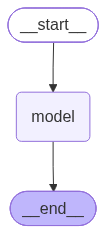

In [6]:
agent

In [7]:
config = {"configurable": {"thread_id": "message-limit-demo"}}

In [9]:
result = agent.invoke({"messages": [("user", "Hi, How are you?")]}, 
                             config=config,)

In [10]:
rprint(result)

{
    'messages': [
        HumanMessage(
            content='Hi, How are you?',
            additional_kwargs={},
            response_metadata={},
            id='b1933603-b586-486e-9336-a3a774f29ce8'
        ),
        AIMessage(
            content="I'm just a language model, so I don't have feelings or emotions like humans do, but I'm 
functioning properly and ready to help with any questions or tasks you might have. How about you? How's your day 
going so far?",
            additional_kwargs={},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 50,
                    'prompt_tokens': 41,
                    'total_tokens': 91,
                    'completion_time': 0.103982014,
                    'completion_tokens_details': None,
                    'prompt_time': 0.001207229,
                    'prompt_tokens_details': None,
                    'queue_time': 0.049522101,
                    'total_time': 0.105189243
                },
                'model_name': 'llama-3.3-70b-versatile',
                'system_fingerprint': 'fp_dae98b5ecb',
                'service_tier': 'on_demand',
                'finish_reason': 'stop',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--01a00d9f-dc29-7c13-84ea-42f682af952c-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={'input_tokens': 41, 'output_tokens': 50, 'total_tokens': 91}
        )
    ]
}